<a href="https://colab.research.google.com/github/mi31417/Insider-Threat-Detection-/blob/main/insider_threat_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

email_df = pd.read_csv('/content/email.csv')
psych_df = pd.read_csv('/content/psychometric.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
email_df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...


In [ ]:
psych_df.head()

,employee_name,user_id,O,C,E,A,N
0,Calvin Edan Love,CEL0561,40,39,36,19,40
1,Christine Reagan Deleon,CRD0624,26,22,17,39,32
2,Jade Felicia Caldwell,JFC0557,22,16,23,40,33
3,Aquila Stewart Dejesus,ASD0577,40,48,36,14,37
4,Micah Abdul Rojas,MAR0955,36,44,23,44,25


Sanity Check of Data

In [ ]:
email_df.shape


(30340, 11)

In [ ]:
psych_df.shape

(1000, 7)

In [ ]:
email_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30340 entries, 0 to 30339
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           30340 non-null  object
 1   date         30340 non-null  object
 2   user         30340 non-null  object
 3   pc           30340 non-null  object
 4   to           30340 non-null  object
 5   cc           13454 non-null  object
 6   bcc          4904 non-null   object
 7   from         30340 non-null  object
 8   size         30340 non-null  int64 
 9   attachments  30340 non-null  int64 
 10  content      30340 non-null  object
dtypes: int64(2), object(9)
memory usage: 2.5+ MB


In [ ]:
psych_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   employee_name  1000 non-null   object
 1   user_id        1000 non-null   object
 2   O              1000 non-null   int64 
 3   C              1000 non-null   int64 
 4   E              1000 non-null   int64 
 5   A              1000 non-null   int64 
 6   N              1000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 54.8+ KB


In [ ]:
email_df.isnull().sum()



,0
id,0
date,0
user,0
pc,0
to,0
cc,16886
bcc,25436
from,0
size,0
attachments,0


In [ ]:
psych_df.isnull().sum()

,0
employee_name,0
user_id,0
O,0
C,0
E,0
A,0
N,0


In [ ]:
# Text fields like 'to', 'cc', 'bcc', 'from', 'content' — replace missing with 'unknown'
for col in ['to', 'cc', 'bcc', 'from', 'content']:
    email_df[col] = email_df[col].fillna('unknown')

# Numeric columns like 'size' and 'attachments' — replace missing with 0
for col in ['size', 'attachments']:
    email_df[col] = email_df[col].fillna(0)

In [ ]:
email_df.isnull().sum()

,0
id,0
date,0
user,0
pc,0
to,0
cc,0
bcc,0
from,0
size,0
attachments,0


In [ ]:
email_df.duplicated().sum()

np.int64(0)

In [ ]:
psych_df.duplicated().sum()

np.int64(0)

In [ ]:
#garbage value
for i in email_df.select_dtypes(include = "object").columns:
  print(email_df[i].value_counts())
  print("***"*10)

id
{O6Z6-H7SB19LF-0027WRBW}    1
{R3I7-S4TX96FG-8219JWFF}    1
{R0R9-E4GL59IK-2907OSWJ}    1
{G2B2-A8XY58CP-2847ZJZL}    1
{V8N4-A7IK29ET-4624OWQT}    1
                           ..
{V3L7-L2RB92RV-9130MFPE}    1
{D9T8-M1HJ89XP-6364INQJ}    1
{H5J6-G2RS59KI-8386FFLL}    1
{X8T7-A6BT54FP-7241DLBV}    1
{E8B7-C8FZ88UF-2946RUQQ}    1
Name: count, Length: 30340, dtype: int64
******************************
date
01/05/2010 09:33:00    6
01/05/2010 09:33:02    5
01/04/2010 09:10:56    4
01/04/2010 14:40:51    4
01/06/2010 15:26:52    4
                      ..
01/05/2010 10:00:46    1
01/05/2010 10:00:45    1
01/05/2010 10:00:38    1
01/05/2010 10:00:37    1
01/05/2010 10:01:15    1
Name: count, Length: 27364, dtype: int64
******************************
user
MSS0001    142
TVS0006    108
KBP0008    105
KWC0004     96
HCS0003     90
          ... 
CCM0467      2
CSL0949      2
JCR0289      2
ILR0304      2
MNR0829      1
Name: count, Length: 1000, dtype: int64
******************************
pc

In [ ]:
#garbage value
for i in psych_df.select_dtypes(include = "object").columns:
  print(psych_df[i].value_counts())
  print("***"*10)

employee_name
Ferris Stone Bender         1
Calvin Edan Love            1
Christine Reagan Deleon     1
Jade Felicia Caldwell       1
Aquila Stewart Dejesus      1
                           ..
Ferris Omar Barry           1
Jacqueline Latifah Miles    1
Devin Abdul Rogers          1
Aurora Sarah Manning        1
Tasha Casey Dalton          1
Name: count, Length: 1000, dtype: int64
******************************
user_id
FSB0399    1
CEL0561    1
CRD0624    1
JFC0557    1
ASD0577    1
          ..
FOB0756    1
JLM0364    1
DAR0885    1
ASM0575    1
TCD0009    1
Name: count, Length: 1000, dtype: int64
******************************


In [ ]:
email_df.describe().T

,count,mean,std,min,25%,50%,75%,max
size,30340.0,29975.435201,10031.316672,8161.0,22789.0,28417.0,35320.25,100737.0
attachments,30340.0,0.465227,1.122837,0.0,0.0,0.0,0.00,9.0


In [ ]:
psych_df.describe().T

,count,mean,std,min,25%,50%,75%,max
O,1000.0,33.173,10.642007,10.0,23.0,36.0,42.0,50.0
C,1000.0,30.653,11.291505,10.0,20.0,33.0,40.0,50.0
E,1000.0,29.197,10.956470,10.0,19.0,28.0,39.0,50.0
A,1000.0,28.821,11.170844,10.0,19.0,27.0,39.0,50.0
N,1000.0,29.608,4.938494,14.0,26.0,29.0,33.0,49.0


In [ ]:
obj_attributes=email_df.describe(include="object")

In [ ]:
obj_attributes.columns

Index(['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'content'], dtype='object')

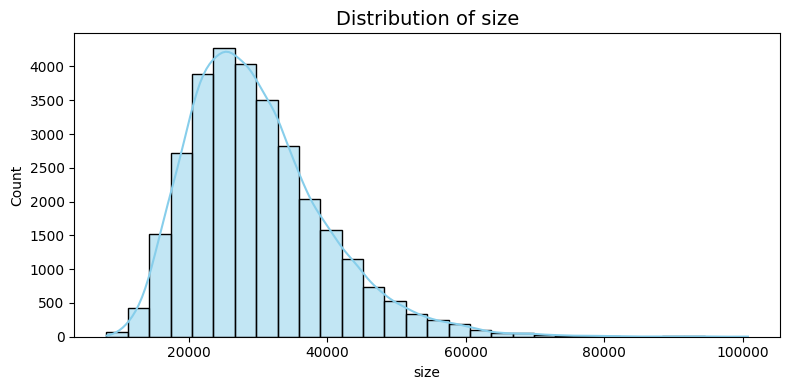

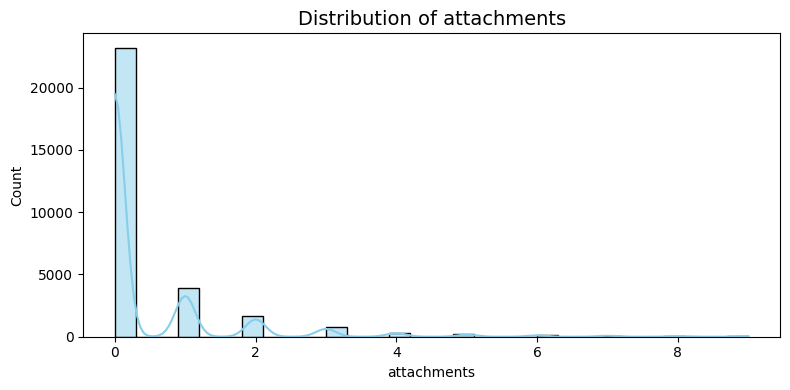

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

numeric_cols = email_df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(data=email_df, x=col, kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()



In [ ]:
email_df.columns

Index(['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size',
       'attachments', 'content'],
      dtype='object')

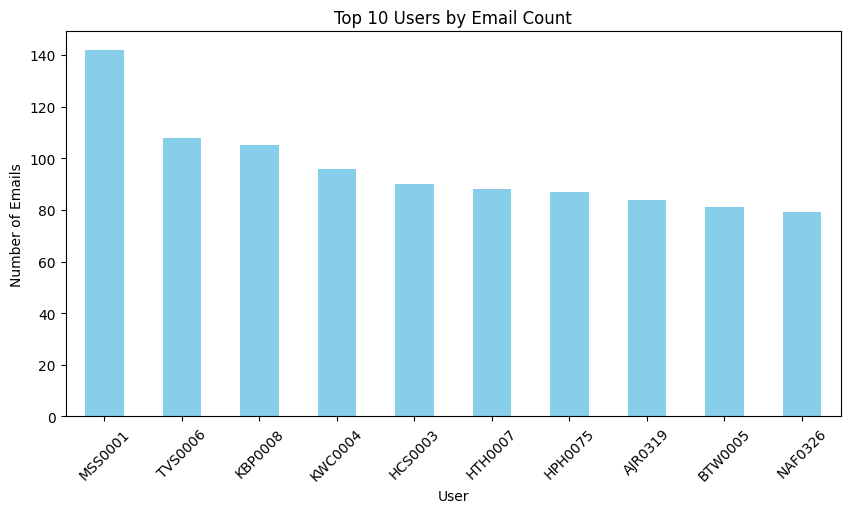

In [ ]:
import matplotlib.pyplot as plt

top_users = email_df['user'].value_counts().head(10)
plt.figure(figsize=(10,5))
top_users.plot(kind='bar', color='skyblue')
plt.title('Top 10 Users by Email Count')
plt.xlabel('User')
plt.ylabel('Number of Emails')
plt.xticks(rotation=45)
plt.show()


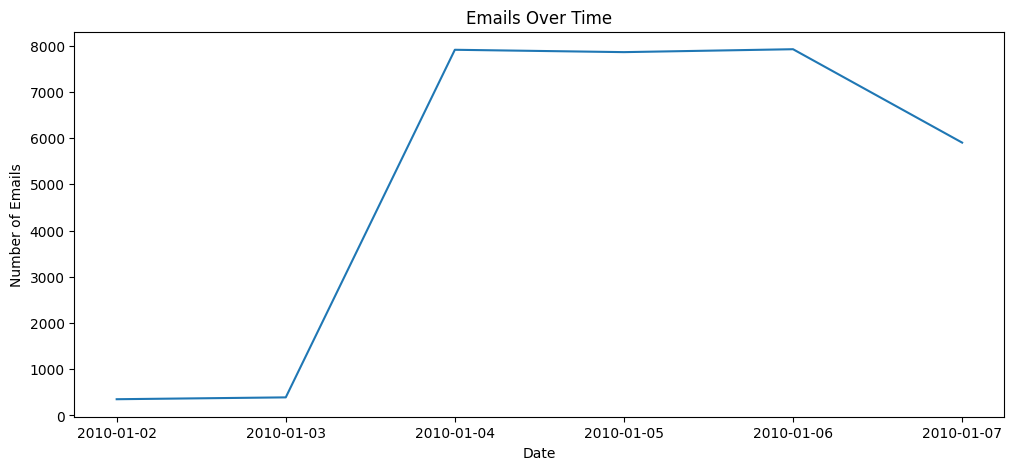

In [ ]:
email_df['date'] = pd.to_datetime(email_df['date'], errors='coerce')
emails_per_day = email_df.groupby(email_df['date'].dt.date).size()

plt.figure(figsize=(12,5))
emails_per_day.plot()
plt.title('Emails Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Emails')
plt.show()


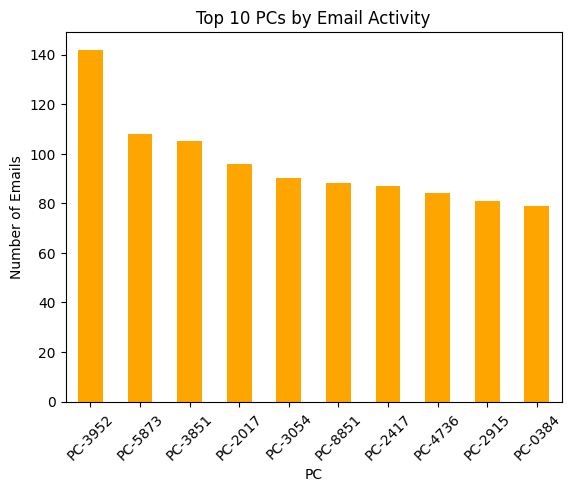

In [ ]:
pc_counts = email_df['pc'].value_counts().head(10)
pc_counts.plot(kind='bar', color='orange')
plt.title('Top 10 PCs by Email Activity')
plt.xlabel('PC')
plt.ylabel('Number of Emails')
plt.xticks(rotation=45)
plt.show()


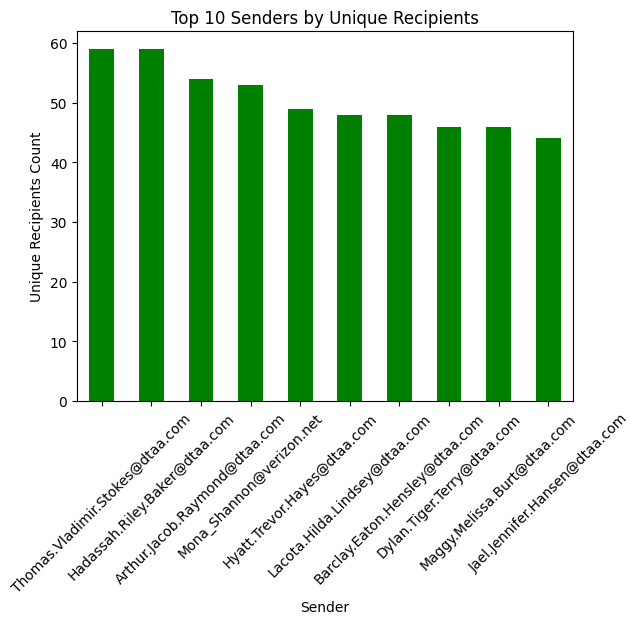

In [ ]:
from_to_count = email_df.groupby('from')['to'].nunique().sort_values(ascending=False).head(10)
from_to_count.plot(kind='bar', color='green')
plt.title('Top 10 Senders by Unique Recipients')
plt.xlabel('Sender')
plt.ylabel('Unique Recipients Count')
plt.xticks(rotation=45)
plt.show()


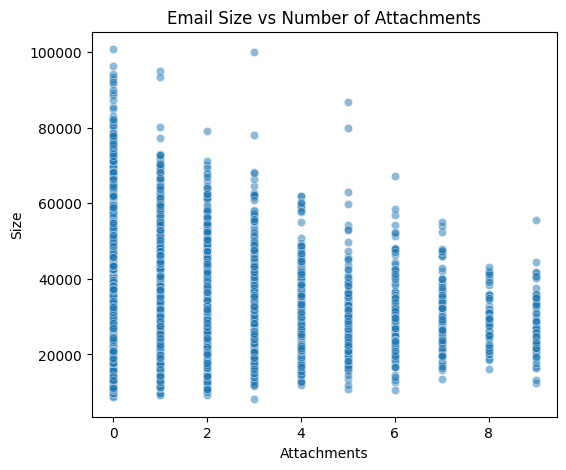

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.scatterplot(data=email_df, x='attachments', y='size', alpha=0.5)
plt.title('Email Size vs Number of Attachments')
plt.xlabel('Attachments')
plt.ylabel('Size')
plt.show()


In [ ]:
email_encoded = email_df.copy()

# Label encode categorical columns
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['user', 'pc', 'to', 'cc', 'bcc', 'from']
encoder = LabelEncoder()

for col in categorical_cols:
    email_encoded[col] = email_encoded[col].astype(str)  # handle NaNs
    email_encoded[col] = encoder.fit_transform(email_encoded[col])

email_encoded.head()


,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,588,553,3737,3614,566,1191,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,675,665,10922,5216,566,1207,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,588,553,11253,5216,566,1192,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},2010-01-02 07:13:17,588,553,7742,5216,566,1192,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},2010-01-02 07:13:28,675,665,1781,5216,408,1207,17319,0,this kmh october holliswood number advised unu...


In [ ]:
corr_all = email_encoded.drop(['id', 'content'], axis=1).corr()

# Display top correlations
corr_all

,date,user,pc,to,cc,bcc,from,size,attachments
date,1.000000,0.008069,0.000543,-0.009235,0.052034,0.052404,0.008695,0.003358,-0.010034
user,0.008069,1.000000,0.062071,-0.009581,0.112765,0.195550,0.908962,-0.005447,0.001407
pc,0.000543,0.062071,1.000000,-0.003967,0.015803,0.026036,0.063648,-0.001982,0.004347
to,-0.009235,-0.009581,-0.003967,1.000000,-0.001230,-0.005746,-0.009856,0.002239,-0.003036
cc,0.052034,0.112765,0.015803,-0.001230,1.000000,0.021302,0.118821,-0.004373,-0.117792
bcc,0.052404,0.195550,0.026036,-0.005746,0.021302,1.000000,0.202941,-0.004133,-0.134763
from,0.008695,0.908962,0.063648,-0.009856,0.118821,0.202941,1.000000,-0.004814,0.009551
size,0.003358,-0.005447,-0.001982,0.002239,-0.004373,-0.004133,-0.004814,1.000000,0.003253
attachments,-0.010034,0.001407,0.004347,-0.003036,-0.117792,-0.134763,0.009551,0.003253,1.000000


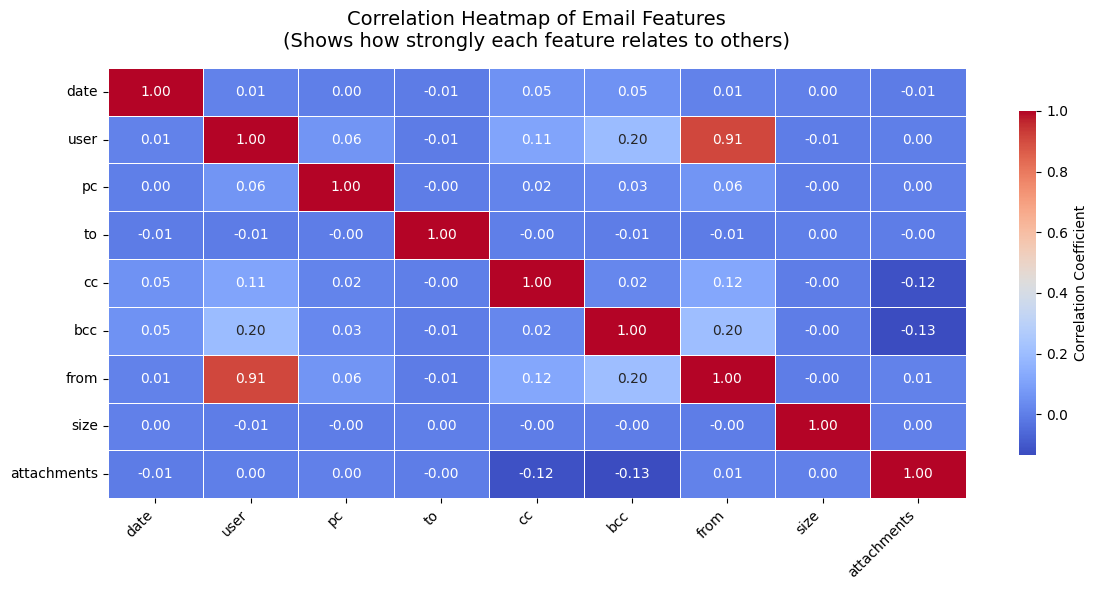

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


corr_all = email_encoded.drop(['id', 'content'], axis=1).corr()

plt.figure(figsize=(12,6))


sns.heatmap(
    corr_all,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)


plt.title(
    'Correlation Heatmap of Email Features\n'
    '(Shows how strongly each feature relates to others)',
    fontsize=14,
    pad=15
)


plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
obj_attributes=psych_df.describe(include="object")

In [ ]:
obj_attributes.columns

Index(['employee_name', 'user_id'], dtype='object')

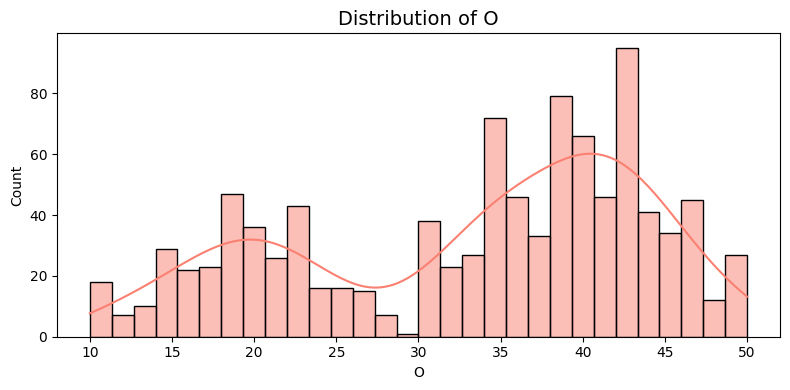

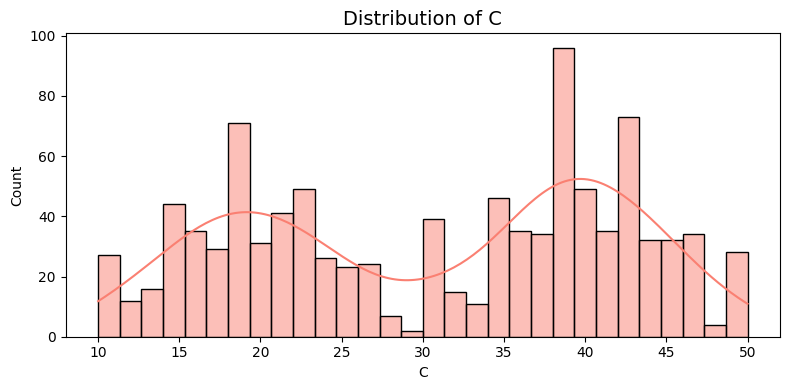

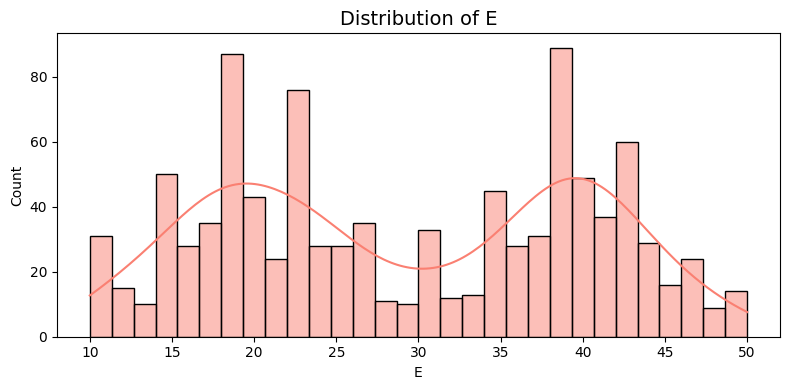

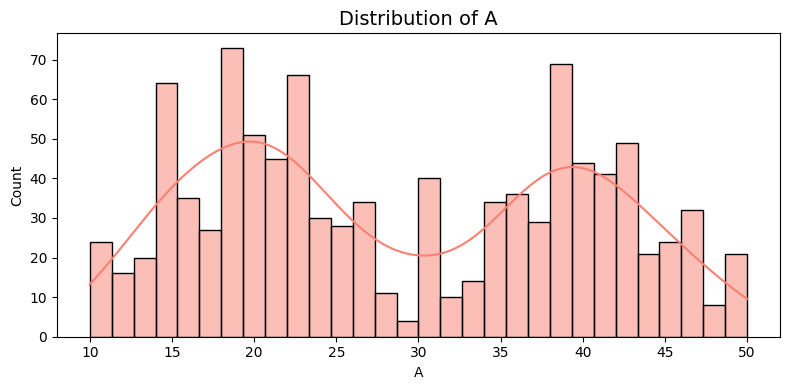

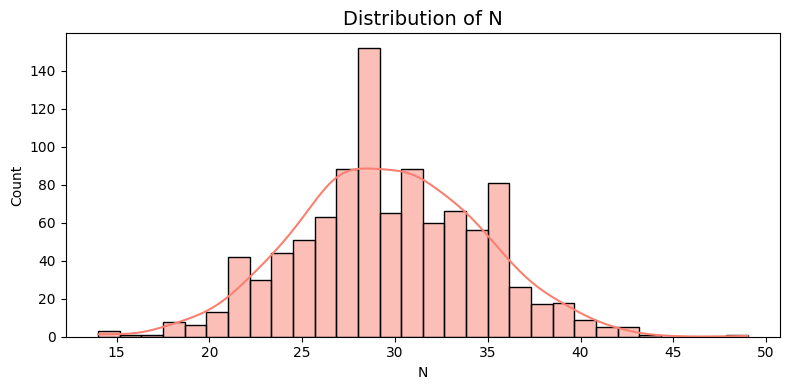

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

numeric_cols_psych = psych_df.select_dtypes(include="number").columns

for col in numeric_cols_psych:
    plt.figure(figsize=(8,4))
    sns.histplot(data=psych_df, x=col, kde=True, bins=30, color='salmon')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


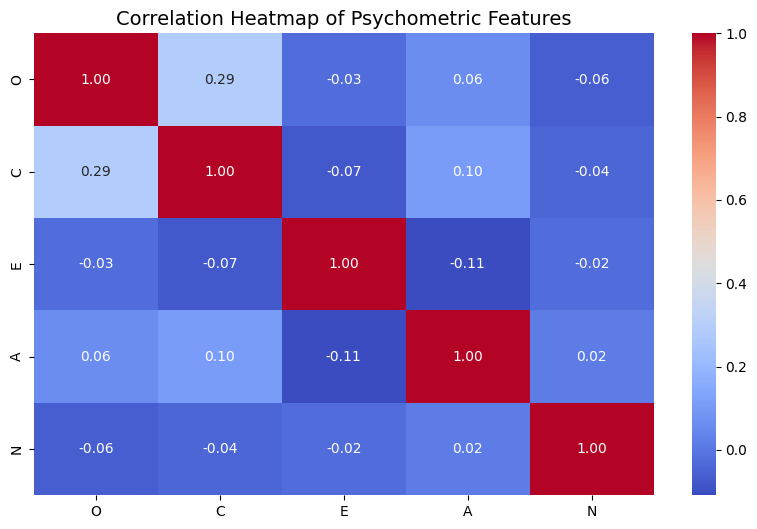

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(psych_df.drop(['employee_name', 'user_id'], axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Psychometric Features', fontsize=14)
plt.show()

**Merge both datsets**

In [ ]:
merged_df = pd.merge(email_df, psych_df, left_on='user', right_on='user_id', how='inner')

print("Merged shape:", merged_df.shape)
merged_df.head()

Merged shape: (30340, 18)


,id,date,user,pc,to,cc,bcc,from,size,attachments,content,employee_name,user_id,O,C,E,A,N
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,unknown,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...,Lynn Adena Pratt,LAP0338,42,23,33,45,31
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,unknown,unknown,MOH68@optonline.net,29942,0,the breaking called allied reservations former...,Macaulay Otto Hopkins,MOH0273,39,40,47,50,26
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,unknown,unknown,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...,Lynn Adena Pratt,LAP0338,42,23,33,45,31
3,{A3A9-F4TH89AA-8318GFGK},2010-01-02 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,unknown,unknown,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...,Lynn Adena Pratt,LAP0338,42,23,33,45,31
4,{E8B7-C8FZ88UF-2946RUQQ},2010-01-02 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,unknown,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...,Macaulay Otto Hopkins,MOH0273,39,40,47,50,26


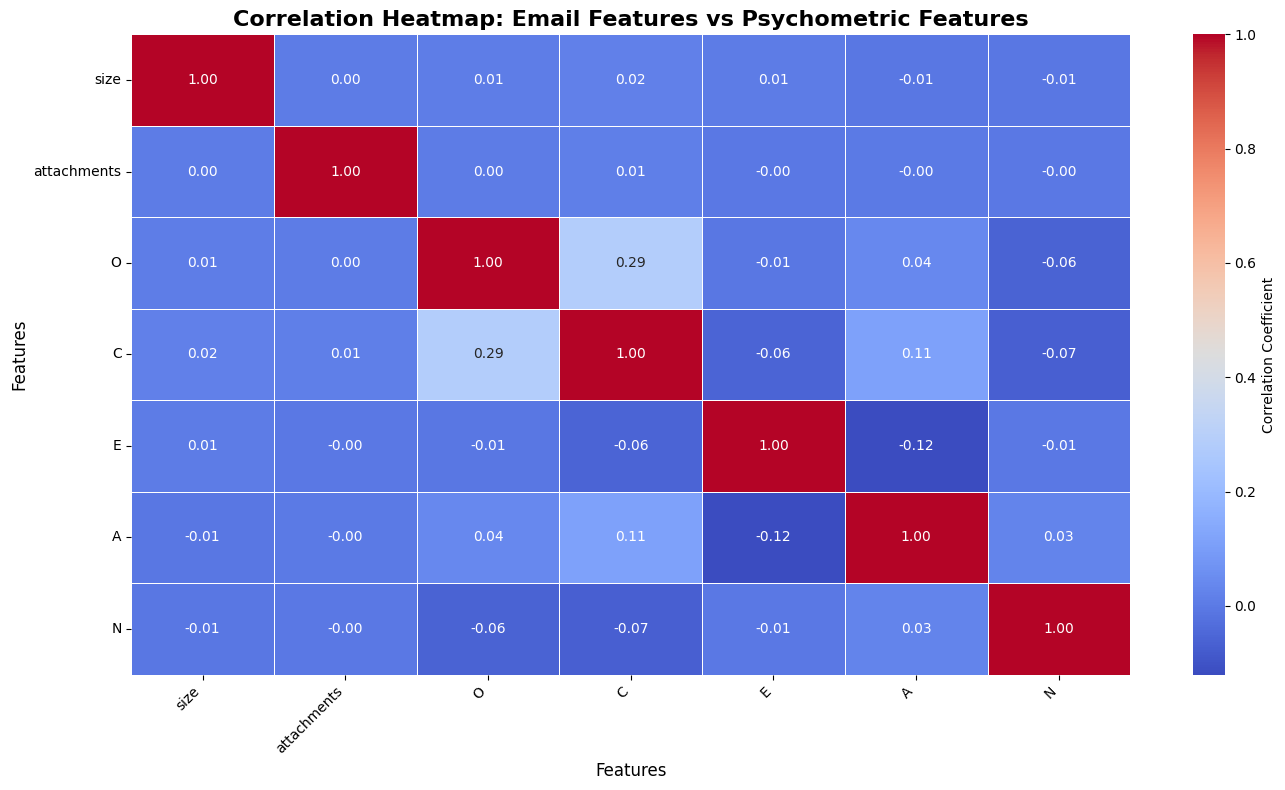

Top 15 Most Correlated Feature Pairs (across Email & Psychometric datasets):

O            C              0.285508
C            O              0.285508
A            C              0.112048
C            A              0.112048
O            A              0.039514
A            O              0.039514
             N              0.025850
N            A              0.025850
size         C              0.016601
C            size           0.016601
attachments  C              0.011633
C            attachments    0.011633
O            size           0.008305
size         O              0.008305
E            size           0.005405
dtype: float64


In [ ]:
merged_numeric = merged_df.select_dtypes(include=['int64', 'float64'])
corr_merged = merged_numeric.corr()

plt.figure(figsize=(14, 8))
sns.heatmap(
    corr_merged,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap: Email Features vs Psychometric Features', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

corr_pairs = corr_merged.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]
print("Top 15 Most Correlated Feature Pairs (across Email & Psychometric datasets):\n")
print(corr_pairs.head(15))


There is a mild positive correlation (≈ 0.28) between Conscientiousness (C) and Openness (O) — users high on these traits might exhibit structured email behavior.Email features (size, attachments) show very low correlation (≈ 0.00–0.01) with psychometric traits — this is expected since human traits don’t directly cause message size or attachment count.However, these weak correlations don’t mean features are useless — they might still contribute non-linear effects.

Hence, it’s best to keep engineered behavioral features, not the raw text-based ones, since they carry more pattern-level meaning.

In [ ]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
selector.fit(merged_numeric)
low_var_cols = merged_numeric.columns[~selector.get_support()]
print("Low variance columns:", low_var_cols)


Low variance columns: Index([], dtype='object')


These features capture communication patterns that might indicate insider threats, such as unusually high email activity, excessive external communication, or sending large attachments. Such behavioral anomalies may signal data exfiltration or suspicious intent.

In [ ]:
# Email communication-based features
merged_df['num_recipients'] = merged_df['to'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
merged_df['has_attachment'] = merged_df['attachments'].apply(lambda x: 1 if x > 0 else 0)
merged_df['is_external'] = merged_df['to'].apply(lambda x: any('@external.com' in str(addr) for addr in str(x).split(',')) if pd.notnull(x) else 0)
merged_df['cc_count'] = merged_df['cc'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
merged_df['bcc_count'] = merged_df['bcc'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)


These time-based features focus on when emails are sent. Insider activities often occur outside office hours. We assume standard office hours are 9 AM to 6 PM (Monday–Friday). Emails sent late at night or on weekends might deserve higher risk weight.

In [ ]:
import pandas as pd

merged_df['date'] = pd.to_datetime(merged_df['date'], errors='coerce')

# Extract temporal features
merged_df['hour'] = merged_df['date'].dt.hour
merged_df['day_of_week'] = merged_df['date'].dt.dayofweek
merged_df['is_weekend'] = merged_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
merged_df['after_office_hours'] = merged_df['hour'].apply(lambda x: 1 if (x < 9 or x > 18) else 0)

# Calculate time gap between consecutive emails per user
merged_df = merged_df.sort_values(['user', 'date'])
merged_df['time_diff'] = merged_df.groupby('user')['date'].diff().dt.total_seconds() / 3600  # in hours
merged_df['time_diff'].fillna(0, inplace=True)


These features aggregate communication and behavioral patterns for each user, helping detect anomalies such as sudden increases in activity or shift in communication style

In [ ]:
# Behavioral aggregation per user
user_activity = merged_df.groupby('user').agg({
    'num_recipients': 'mean',
    'has_attachment': 'sum',
    'is_external': 'mean',
    'cc_count': 'mean',
    'bcc_count': 'mean',
    'after_office_hours': 'mean',
    'time_diff': 'mean'
}).reset_index()

user_activity.columns = ['user', 'avg_recipients', 'total_attachments', 'avg_external_ratio',
                         'avg_cc', 'avg_bcc', 'avg_after_office', 'avg_time_gap']


These features are derived from the psychometric assessments. Personality traits like low conscientiousness or high neuroticism have been linked in research to risky or non-compliant insider behavior. These can be combined with behavioral indicators for better detection.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

psych_cols = ['O', 'C', 'E', 'A', 'N']
scaler = MinMaxScaler()
merged_df[psych_cols] = scaler.fit_transform(merged_df[psych_cols])

# Aggregate psychometric scores per user
psych_summary = merged_df.groupby('user')[psych_cols].mean().reset_index()

In [ ]:
# Merge all engineered feature sets
final_features = pd.merge(user_activity, psych_summary, on='user', how='left')

print("Final dataset shape:", final_features.shape)
final_features.head()


Final dataset shape: (1000, 13)


,user,avg_recipients,total_attachments,avg_external_ratio,avg_cc,avg_bcc,avg_after_office,avg_time_gap,O,C,E,A,N
0,AAE0190,1.0,8,0.0,1.0,1.0,0.317073,1.357683,0.650,0.500,0.100,1.000,0.428571
1,AAF0535,1.0,5,0.0,1.0,1.0,0.000000,6.681136,0.175,0.275,0.650,0.575,0.485714
2,AAF0791,1.0,0,0.0,1.0,1.0,0.000000,2.601954,0.100,0.750,0.750,1.000,0.571429
3,AAL0706,1.0,0,0.0,1.0,1.0,0.250000,16.077778,0.675,0.100,0.450,0.075,0.314286
4,AAM0658,1.0,4,0.0,1.0,1.0,0.200000,7.093139,0.825,0.625,0.675,0.650,0.228571


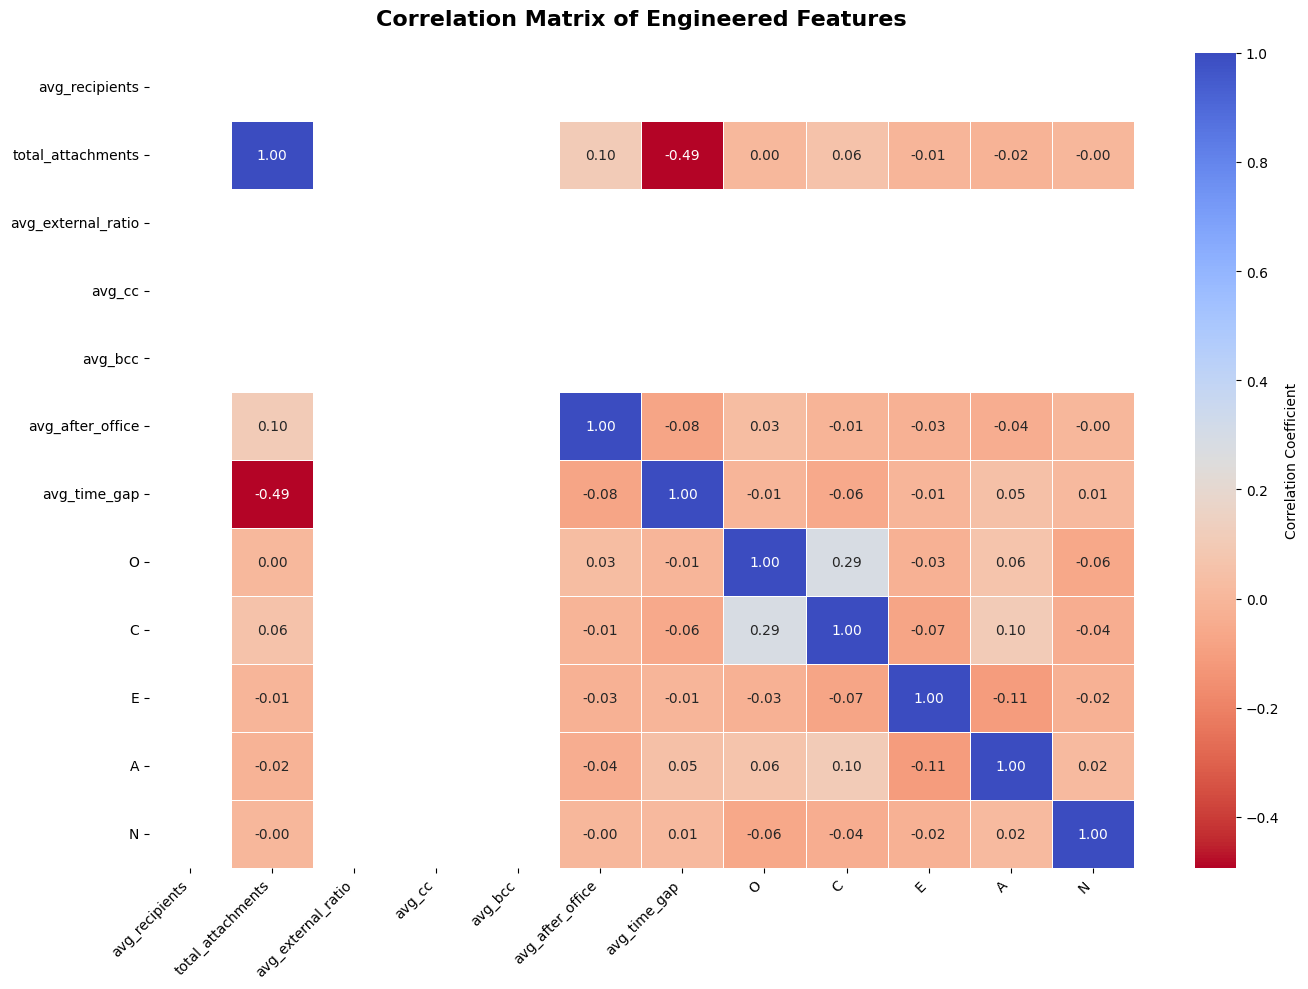

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = final_features.drop('user', axis=1).corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    cmap='coolwarm_r',
    annot=True,
    fmt=".2f",
    linewidths=0.6,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title("Correlation Matrix of Engineered Features", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

The correlation matrix indicates mostly weak relationships among features. Avg Time Gap and Total Attachments show a moderate negative correlation (-0.49) with the target. White areas represent independent features such as avg_external_ratio, avg_cc, and avg_bcc, showing minimal linear association.

In [ ]:
# Overview of merged dataset
merged_df.info()

# Optional: quick null summary
merged_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 30340 entries, 1355 to 28496
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  30340 non-null  object        
 1   date                30340 non-null  datetime64[ns]
 2   user                30340 non-null  object        
 3   pc                  30340 non-null  object        
 4   to                  30340 non-null  object        
 5   cc                  30340 non-null  object        
 6   bcc                 30340 non-null  object        
 7   from                30340 non-null  object        
 8   size                30340 non-null  int64         
 9   attachments         30340 non-null  int64         
 10  content             30340 non-null  object        
 11  employee_name       30340 non-null  object        
 12  user_id             30340 non-null  object        
 13  O                   30340 non-null  float64     

,0
id,0
date,0
user,0
pc,0
to,0
cc,0
bcc,0
from,0
size,0
attachments,0


In [ ]:
drop_cols = ['id', 'user', 'employee_name', 'user_id',
              'date', 'content', 'pc', 'to', 'cc', 'bcc', 'from']

merged_df.drop(drop_cols, axis=1, inplace=True)


In [ ]:
# Overview of merged dataset
merged_df.info()

# Optional: quick null summary
merged_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 30340 entries, 1355 to 28496
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   size                30340 non-null  int64  
 1   attachments         30340 non-null  int64  
 2   O                   30340 non-null  float64
 3   C                   30340 non-null  float64
 4   E                   30340 non-null  float64
 5   A                   30340 non-null  float64
 6   N                   30340 non-null  float64
 7   num_recipients      30340 non-null  int64  
 8   has_attachment      30340 non-null  int64  
 9   is_external         30340 non-null  bool   
 10  cc_count            30340 non-null  int64  
 11  bcc_count           30340 non-null  int64  
 12  hour                30340 non-null  int32  
 13  day_of_week         30340 non-null  int32  
 14  is_weekend          30340 non-null  int64  
 15  after_office_hours  30340 non-null  int64  
 16  time_d

,0
size,0
attachments,0
O,0
C,0
E,0
A,0
N,0
num_recipients,0
has_attachment,0
is_external,0


ince our dataset contains features on different scales—such as psychometric scores (O, C, E, A, N), email metrics (num_recipients, cc_count, bcc_count, hour, day_of_week, time_diff), and binary indicators (has_attachment, is_external, is_weekend, after_office_hours)—we applied standard normalization to the numeric features. This scales each feature to have a mean of 0 and standard deviation of 1, ensuring that no single feature dominates distance-based computations in anomaly detection or clustering. Binary features were kept as 0/1 values.

In [ ]:
merged_df.head()

,size,attachments,O,C,E,A,N,num_recipients,has_attachment,is_external,cc_count,bcc_count,hour,day_of_week,is_weekend,after_office_hours,time_diff
1355,34681,0,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,0,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.386257
1368,28760,0,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,0,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.384700
1378,33604,0,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,0,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.385189
1510,16229,0,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,0,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.360909
1511,24158,3,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,1,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.386123


In [ ]:
from sklearn.preprocessing import StandardScaler

num_cols = ['O','C','E','A','N','num_recipients','cc_count','bcc_count','hour','day_of_week','time_diff']

scaler = StandardScaler()
merged_df[num_cols] = scaler.fit_transform(merged_df[num_cols])

In [ ]:
merged_df.head()

,size,attachments,O,C,E,A,N,num_recipients,has_attachment,is_external,cc_count,bcc_count,hour,day_of_week,is_weekend,after_office_hours,time_diff
1355,34681,0,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,0,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.386257
1368,28760,0,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,0,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.384700
1378,33604,0,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,0,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.385189
1510,16229,0,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,0,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.360909
1511,24158,3,0.270955,-0.094954,-1.3863,1.920392,-0.126271,0.0,1,False,0.0,0.0,-1.325241,-1.202375,0,1,-0.386123


In [ ]:
from sklearn.ensemble import IsolationForest

# Define binary columns
binary_cols = ['has_attachment', 'is_external', 'is_weekend', 'after_office_hours']

# Initialize Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)  # 5% potential insiders
iso.fit(merged_df[num_cols + binary_cols])

# Predict anomalies (-1 = anomaly, 1 = normal)
merged_df['iso_anomaly'] = iso.predict(merged_df[num_cols + binary_cols])

# Convert to 0 = normal, 1 = anomaly
merged_df['iso_anomaly'] = merged_df['iso_anomaly'].map({1: 0, -1: 1})

# Check number of anomalies
print("Number of anomalies detected by Isolation Forest:", merged_df['iso_anomaly'].sum())

Number of anomalies detected by Isolation Forest: 1517


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:

iso_anomalies = merged_df[merged_df['iso_anomaly'] == 1]
print(iso_anomalies[num_cols + binary_cols].head())

# Compare mean values vs normal users
iso_normal = merged_df[merged_df['iso_anomaly'] == 0]

print("Average feature values for anomalies:")
print(iso_anomalies[num_cols + binary_cols].mean())

print("\nAverage feature values for normal users:")
print(iso_normal[num_cols + binary_cols].mean())

              O         C         E         A         N  num_recipients  \
30207 -1.827957  0.787001  0.993512  1.920392  0.889011             0.0   
8541   0.938790  0.346024  0.718919  0.666914 -1.547665             0.0   
8603   0.938790  0.346024  0.718919  0.666914 -1.547665             0.0   
23983 -0.873906 -1.329692  1.451169 -0.407495 -0.329327             0.0   
16178  1.034195 -0.624127  0.627387  1.114585  0.685954             0.0   

       cc_count  bcc_count      hour  day_of_week  time_diff  has_attachment  \
30207       0.0        0.0  0.696048     1.202481   3.860334               0   
8541        0.0        0.0  2.380456    -1.202375   0.719494               0   
8603        0.0        0.0  2.380456    -1.202375  -0.291535               1   
23983       0.0        0.0  1.706693     0.400862   3.609078               1   
16178       0.0        0.0  1.706693    -0.400756   4.470954               0   

       is_external  is_weekend  after_office_hours  
30207        Fa

Isolation Forest flagged 1,517 potential anomalies. These anomalies show similar psychometric scores to normal users, but differ in email behavior — they are more likely to send emails on weekends, after office hours, include attachments, and have unusual timing patterns. This indicates that the model primarily detects deviations in communication behavior rather than personality traits.

**K-Means Clustering**

In [ ]:
from sklearn.cluster import KMeans

# Initialize KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init for newer sklearn versions
merged_df['kmeans_cluster'] = kmeans.fit_predict(merged_df[num_cols + binary_cols])

# Check cluster sizes
print(merged_df['kmeans_cluster'].value_counts())

kmeans_cluster
1    15206
2    12198
0     2936
Name: count, dtype: int64


In [ ]:
merged_df.groupby('kmeans_cluster')[num_cols + binary_cols].mean()


,O,C,E,A,N,num_recipients,cc_count,bcc_count,hour,day_of_week,time_diff,has_attachment,is_external,is_weekend,after_office_hours
kmeans_cluster,,,,,,,,,,,,,,,
0,-0.000053,-0.036257,0.006839,0.025629,-0.001643,0.0,0.0,0.0,-0.486021,0.360454,2.918660,0.234332,0.0,0.008856,0.286785
1,0.422771,0.744458,-0.093944,0.205306,-0.052105,0.0,0.0,0.0,0.067458,-0.036058,-0.312836,0.236880,0.0,0.025845,0.141392
2,-0.527013,-0.919313,0.115464,-0.262103,0.065349,0.0,0.0,0.0,0.032890,-0.041809,-0.312526,0.234629,0.0,0.026316,0.148385


K-Means grouped users into three clusters. The smallest cluster shows unusual email behavior — longer gaps between emails, activity outside office hours, weekend emails, and more attachments — making these users potential anomalies. The other clusters represent typical or slightly atypical behavior.

In [ ]:
from sklearn.cluster import DBSCAN

#  (re-defining for clarity in this cell)
num_cols = ['O','C','E','A','N','num_recipients','cc_count','bcc_count','hour','day_of_week','time_diff']
binary_cols = ['has_attachment', 'is_external', 'is_weekend', 'after_office_hours']

dbscan = DBSCAN(eps=2, min_samples=5)
merged_df['dbscan_cluster'] = dbscan.fit_predict(merged_df[num_cols + binary_cols])

# Flag outliers (-1 = outlier)
merged_df['dbscan_anomaly'] = merged_df['dbscan_cluster'].apply(lambda x: 1 if x == -1 else 0)
print("Number of DBSCAN anomalies:", merged_df['dbscan_anomaly'].sum())

Number of DBSCAN anomalies: 73


DBSCAN identified 73 outliers in the dataset. These are users whose behavior falls outside dense regions of typical activity, making them high-confidence anomalies. Compared to Isolation Forest, DBSCAN is stricter and flags only the most extreme deviations in email timing, weekend or after-hours activity, and attachment patterns.

In [ ]:
# Isolation Forest, DBSCAN, and K-Means small cluster
comparison_df = pd.DataFrame({
    'Isolation_Forest': merged_df['iso_anomaly'],
    'DBSCAN': merged_df['dbscan_anomaly'],
    'KMeans_Cluster0': (merged_df['kmeans_cluster'] == 0).astype(int)
})

# Users flagged by all three methods
comparison_df['high_confidence'] = comparison_df.sum(axis=1) == 3

# Counts
print("Number of users flagged by Isolation Forest:", comparison_df['Isolation_Forest'].sum())
print("Number of users flagged by DBSCAN:", comparison_df['DBSCAN'].sum())
print("Number of users in K-Means small cluster (0):", comparison_df['KMeans_Cluster0'].sum())
print("Number of users flagged by all three methods (high-confidence anomalies):", comparison_df['high_confidence'].sum())


comparison_df.head()


Number of users flagged by Isolation Forest: 1517
Number of users flagged by DBSCAN: 73
Number of users in K-Means small cluster (0): 2936
Number of users flagged by all three methods (high-confidence anomalies): 62


,Isolation_Forest,DBSCAN,KMeans_Cluster0,high_confidence
1355,0,0,0,False
1368,0,0,0,False
1378,0,0,0,False
1510,0,0,0,False
1511,0,0,0,False


We compared three unsupervised methods to detect unusual user behavior. Isolation Forest flagged 1,517 potential anomalies, DBSCAN detected 73 strict outliers, and K-Means identified 2,936 users in the smallest cluster with atypical patterns. The overlap across all three methods yielded 62 high-confidence anomalies, representing users whose email behavior (after-hours activity, weekend emails, longer time gaps, and attachments) deviates most from the norm. These users are likely the most suspicious and should be prioritized for further investigation.

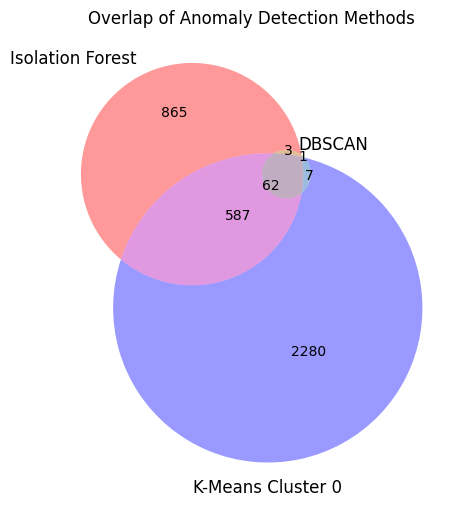

In [ ]:

!pip install matplotlib-venn

import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Prepare sets for Venn diagram
iso_set = set(merged_df.index[merged_df['iso_anomaly'] == 1])
dbscan_set = set(merged_df.index[merged_df['dbscan_anomaly'] == 1])
kmeans_set = set(merged_df.index[merged_df['kmeans_cluster'] == 0])

plt.figure(figsize=(8, 6))
venn3([iso_set, dbscan_set, kmeans_set],
      set_labels=('Isolation Forest', 'DBSCAN', 'K-Means Cluster 0'))
plt.title("Overlap of Anomaly Detection Methods")
plt.show()


Shows the overlap of anomalies detected by Isolation Forest, DBSCAN, and K-Means Cluster 0, highlighting the 62 high-confidence users flagged by all three methods.

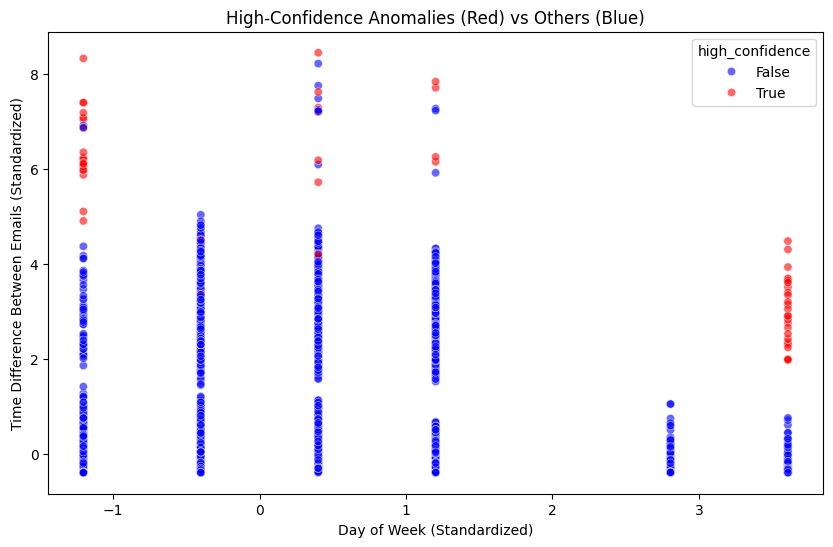

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


comparison_df['high_confidence'] = (comparison_df['Isolation_Forest'] == 1) & \
                                   (comparison_df['DBSCAN'] == 1) & \
                                   (merged_df['kmeans_cluster'] == 0)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged_df,
    x='day_of_week',
    y='time_diff',
    hue=comparison_df['high_confidence'],
    palette={False:'blue', True:'red'},
    alpha=0.6
)
plt.title("High-Confidence Anomalies (Red) vs Others (Blue)")
plt.xlabel("Day of Week (Standardized)")
plt.ylabel("Time Difference Between Emails (Standardized)")
plt.show()

Visualizes high-confidence anomalies (red) versus normal users (blue) using time_diff and day_of_week, showing how unusual email timing separates anomalous behavior from the norm.